# Laboratorio 4 — Fundamentos de Aprendizaje por Refuerzo y Gymnasium

**CC3092 — Deep Learning y Sistemas Inteligentes**  
## Objetivos

1. Investigar los fundamentos del aprendizaje por refuerzo (RL) y la API de Gymnasium.
2. Explorar los entornos `CartPole-v1` y `FrozenLake-v1` con un agente aleatorio.
3. Comparar el agente aleatorio con una política heurística no aprendida para CartPole.

Las ejecuciones usan semillas fijas para que los resultados sean reproducibles.

In [1]:
import sys
import random
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)

print(f"Python: {sys.version.split()[0]}")
print(f"Gymnasium: {gym.__version__}")
print(f"NumPy: {np.__version__}")
print("Gymnasium se importó correctamente.")

Python: 3.14.7
Gymnasium: 1.3.0
NumPy: 2.5.2
Gymnasium se importó correctamente.


## 1. Fundamentos del aprendizaje por refuerzo

### ¿Qué es RL?

En aprendizaje por refuerzo, un **agente** toma acciones en un **entorno** y recibe recompensas. Su objetivo es aprender una política que maximice el retorno acumulado esperado, no solo una recompensa inmediata. A diferencia del aprendizaje supervisado, no recibe pares de entrada-etiqueta correctos; a diferencia del no supervisado, cuenta con una señal evaluativa explícita (la recompensa) y sus acciones cambian los datos futuros que observa. [1]

### Componentes

- **Agente:** quien decide.
- **Entorno:** sistema con el que el agente interactúa.
- **Estado $s$:** información que resume la situación actual.
- **Acción $a$:** decisión disponible para el agente.
- **Recompensa $r$:** señal escalar inmediata que evalúa una transición.
- **Política $\pi(a|s)$:** regla que asigna acciones, o probabilidades de acciones, a cada estado. [1]

### Proceso de Decisión de Markov (MDP)

Un MDP se expresa como $(\mathcal{S}, \mathcal{A}, P, R, \gamma)$: conjunto de estados, conjunto de acciones, función de transición $P(s'|s,a)$, función de recompensa $R(s,a,s')$ y factor de descuento $\gamma\in[0,1]$. La propiedad de Markov indica que, dado el estado actual y la acción, el siguiente estado no depende de la historia anterior. El descuento reduce el peso de recompensas lejanas y permite priorizar retornos cercanos. [1]

### Funciones de valor y ecuación de Bellman

La función de valor de estado $V_\pi(s)$ es el retorno esperado al iniciar en $s$ y seguir $\pi$; $Q_\pi(s,a)$ es el retorno esperado al iniciar en $s$, tomar $a$ y continuar con $\pi$. Una política óptima puede elegirse de forma codiciosa respecto de $Q_*(s,a)$: $\pi_*(s)=\arg\max_a Q_*(s,a)$. La ecuación de Bellman descompone un valor en recompensa inmediata más el valor descontado del siguiente estado; esta relación recursiva hace posible evaluar y mejorar políticas. [1]

### Exploración, explotación y familias de métodos

**Explotar** es elegir la acción actualmente mejor valorada; **explorar** es probar acciones con información incierta. `epsilon-greedy` elige una acción aleatoria con probabilidad $\epsilon$; softmax/Boltzmann asigna mayor probabilidad a acciones con mayor valor, controlada por una temperatura. Las tareas **episódicas** terminan (por ejemplo, CartPole); las **continuas** no tienen terminación natural. Los métodos **on-policy** aprenden sobre la política que generan los datos; los **off-policy** aprenden una política objetivo distinta de la política de comportamiento. Los métodos **model-based** usan o aprenden transiciones/recompensas; los **model-free** aprenden valores o políticas directamente a partir de experiencia. [1]

### Q-Learning

Q-Learning es model-free y off-policy. Actualiza

$$Q(s,a) \leftarrow Q(s,a)+\alpha\,[r+\gamma\max_{a'}Q(s',a')-Q(s,a)].$$

La tasa $\alpha$ controla cuánto cambia la estimación por cada experiencia, y $\gamma$ controla la importancia de recompensas futuras. [1, 2]

## 2. La librería Gymnasium

Gymnasium es una API mantenida para desarrollar y comparar agentes de RL. Es la continuación comunitaria de OpenAI Gym y conserva una interfaz compatible con gran parte de su ecosistema. Un entorno se crea con `gym.make(id)` y se controla con este ciclo:

- `reset(seed=...)` inicia un episodio y retorna `(observation, info)`.
- `step(action)` aplica una acción y retorna `(observation, reward, terminated, truncated, info)`.
- `render()` produce una visualización cuando el modo de renderizado lo permite.
- `close()` libera los recursos del entorno.

`terminated` marca una terminación definida por la tarea, mientras que `truncated` indica un corte externo, como un límite de tiempo. [3, 4]

### Espacios

- **Discrete(n):** entero entre `0` y `n-1`; se usa para acciones como izquierda/derecha o movimientos de cuadrícula.
- **Box:** vector o matriz numérica acotada; se usa para observaciones o acciones continuas.
- **MultiDiscrete:** vector cuyos componentes tienen rangos discretos independientes; es útil cuando una acción o estado combina varias decisiones categóricas. [4]

### Entornos explorados del catálogo

| Entorno | Objetivo | Observación | Acción |
|---|---|---|---|
| `CartPole-v1` | Mantener vertical un poste sobre un carro. | `Box(4,)`: posición, velocidad, ángulo y velocidad angular. | `Discrete(2)`: izquierda/derecha. |
| `MountainCar-v0` | Llevar un auto a la cima de una colina. | `Box(2,)`: posición y velocidad. | `Discrete(3)`: izquierda, neutro, derecha. |
| `FrozenLake-v1` | Llegar a la meta evitando agujeros sobre hielo. | `Discrete(16)` en el mapa 4×4. | `Discrete(4)`: movimientos cardinales. |
| `Taxi-v3` | Recoger y dejar un pasajero en el destino correcto. | `Discrete(500)`. | `Discrete(6)`: movimiento, recoger y dejar. |

Un **wrapper** modifica un entorno sin cambiar su lógica central. `TimeLimit` limita la duración, `RecordVideo` registra episodios y los wrappers de normalización transforman observaciones para facilitar el aprendizaje. [3, 5]

## 3. Módulo de prueba: primeros pasos con Gymnasium

In [2]:
cartpole = gym.make("CartPole-v1")
print("Espacio de observación:", cartpole.observation_space)
print("  Tipo:", type(cartpole.observation_space).__name__)
print("  Dimensión:", cartpole.observation_space.shape)
print("  Límites inferiores:", cartpole.observation_space.low)
print("  Límites superiores:", cartpole.observation_space.high)
print("\nEspacio de acción:", cartpole.action_space)
print("  Tipo:", type(cartpole.action_space).__name__)
print("  Número de acciones:", cartpole.action_space.n)
cartpole.close()

print("\nInterpretación: CartPole observa cuatro valores continuos y permite dos acciones discretas: 0 (izquierda) y 1 (derecha).")

Espacio de observación: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
  Tipo: Box
  Dimensión: (4,)
  Límites inferiores: [-4.8               -inf -0.41887903        -inf]
  Límites superiores: [4.8               inf 0.41887903        inf]

Espacio de acción: Discrete(2)
  Tipo: Discrete
  Número de acciones: 2

Interpretación: CartPole observa cuatro valores continuos y permite dos acciones discretas: 0 (izquierda) y 1 (derecha).


In [3]:
def run_episode(env, policy, seed):
    observation, info = env.reset(seed=seed)
    terminated = truncated = False
    total_reward = 0.0
    steps = 0

    while not (terminated or truncated):
        action = policy(observation, env)
        observation, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1

    return {"steps": steps, "return": total_reward, "terminated": terminated, "truncated": truncated}


def evaluate(env_id, policy, episodes=5, base_seed=SEED, **make_kwargs):
    env = gym.make(env_id, **make_kwargs)
    env.action_space.seed(base_seed)
    results = [run_episode(env, policy, base_seed + episode) for episode in range(episodes)]
    env.close()
    return results


def random_policy(observation, env):
    return env.action_space.sample()


def print_results(title, results):
    print(title)
    print(f"{'Episodio':>9} | {'Pasos':>5} | {'Retorno':>7}")
    print("-" * 31)
    for episode, result in enumerate(results, start=1):
        print(f"{episode:>9} | {result['steps']:>5} | {result['return']:>7.1f}")
    returns = [result["return"] for result in results]
    print("-" * 31)
    print(f"Promedio de retorno: {np.mean(returns):.2f}")


def plot_returns(results, title, color):
    episodes = np.arange(1, len(results) + 1)
    returns = [result["return"] for result in results]
    plt.figure(figsize=(7, 4))
    plt.plot(episodes, returns, marker="o", color=color)
    plt.xticks(episodes)
    plt.xlabel("Episodio")
    plt.ylabel("Recompensa total (return)")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.show()

### 3.1 Agente aleatorio en CartPole-v1

CartPole-v1 — agente aleatorio
 Episodio | Pasos | Retorno
-------------------------------
        1 |    44 |    44.0
        2 |    18 |    18.0
        3 |    12 |    12.0
        4 |    15 |    15.0
        5 |    20 |    20.0
-------------------------------
Promedio de retorno: 21.80


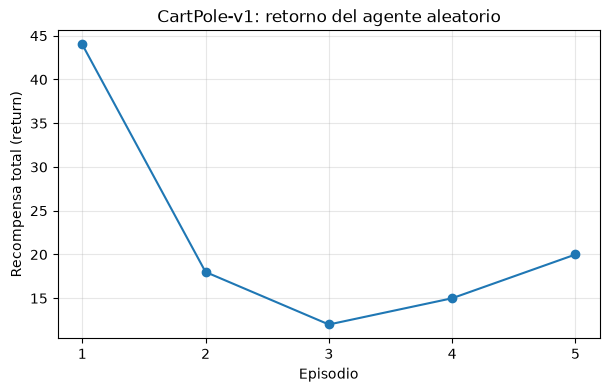

In [4]:
cartpole_random = evaluate("CartPole-v1", random_policy, episodes=5)
print_results("CartPole-v1 — agente aleatorio", cartpole_random)
plot_returns(cartpole_random, "CartPole-v1: retorno del agente aleatorio", "tab:blue")

### 3.2 Agente aleatorio en FrozenLake-v1

Se usa el entorno discreto `FrozenLake-v1` con la configuración predeterminada. La recompensa vale 1 únicamente al alcanzar la meta y 0 en otro caso; por ello, la señal es escasa y el retorno aleatorio normalmente es bajo.

FrozenLake-v1 — agente aleatorio
 Episodio | Pasos | Retorno
-------------------------------
        1 |     8 |     0.0
        2 |    11 |     0.0
        3 |    11 |     0.0
        4 |    12 |     0.0
        5 |     2 |     0.0
-------------------------------
Promedio de retorno: 0.00


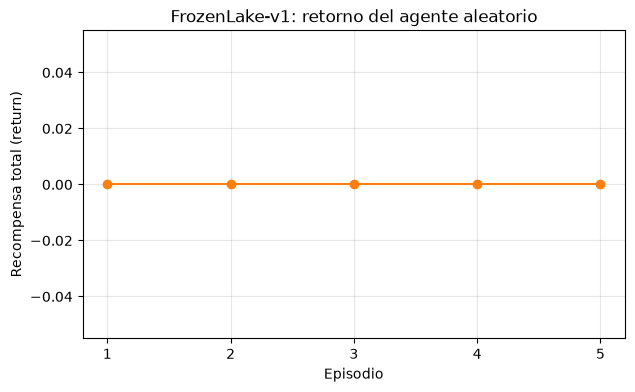

In [5]:
frozenlake_random = evaluate("FrozenLake-v1", random_policy, episodes=5)
print_results("FrozenLake-v1 — agente aleatorio", frozenlake_random)
plot_returns(frozenlake_random, "FrozenLake-v1: retorno del agente aleatorio", "tab:orange")

**Comparación inicial.** En CartPole cada paso que mantiene el sistema activo entrega recompensa positiva, por lo que incluso una secuencia aleatoria puede acumular retorno durante decenas de pasos. FrozenLake ofrece una recompensa terminal escasa: el agente debe llegar exactamente a la meta y evitar agujeros, así que acciones aleatorias suelen terminar sin retorno. Además, CartPole es un problema de control con observación continua, mientras que FrozenLake es una navegación de estados discretos.

### 3.3 Política simple no aprendida para CartPole-v1

CartPole-v1 — política de velocidad angular
 Episodio | Pasos | Retorno
-------------------------------
        1 |   235 |   235.0
        2 |   172 |   172.0
        3 |   201 |   201.0
        4 |   239 |   239.0
        5 |   174 |   174.0
-------------------------------
Promedio de retorno: 204.20

Promedio aleatorio: 21.80
Promedio política simple: 204.20


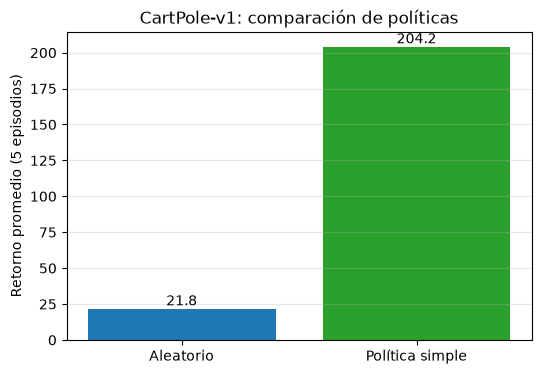

In [6]:
def angular_velocity_policy(observation, env):
    return int(observation[3] > 0)


cartpole_heuristic = evaluate("CartPole-v1", angular_velocity_policy, episodes=5)
print_results("CartPole-v1 — política de velocidad angular", cartpole_heuristic)

random_mean = np.mean([result["return"] for result in cartpole_random])
heuristic_mean = np.mean([result["return"] for result in cartpole_heuristic])
print(f"\nPromedio aleatorio: {random_mean:.2f}")
print(f"Promedio política simple: {heuristic_mean:.2f}")

labels = ["Aleatorio", "Política simple"]
means = [random_mean, heuristic_mean]
plt.figure(figsize=(6, 4))
bars = plt.bar(labels, means, color=["tab:blue", "tab:green"])
plt.ylabel("Retorno promedio (5 episodios)")
plt.title("CartPole-v1: comparación de políticas")
plt.bar_label(bars, fmt="%.1f")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 4. Discusión y análisis

1. **CartPole frente a FrozenLake.** Los resultados muestran retornos más altos en CartPole para el agente aleatorio porque recibe una recompensa por cada paso que sobrevive. En FrozenLake, la recompensa normalmente solo aparece al alcanzar la meta; una política aleatoria rara vez completa la secuencia correcta. La naturaleza de control continuo de CartPole y la navegación discreta con recompensa escasa de FrozenLake explican la diferencia.

2. **Política simple frente al agente aleatorio.** La comparación anterior indica si la heurística superó al agente aleatorio con esta semilla. Si su retorno promedio es mayor, demuestra que conocimiento mínimo del dominio —usar la velocidad angular para contrarrestar la caída— puede mejorar una política sin entrenamiento. Sin embargo, la regla no es necesariamente óptima: ignora posición, velocidad del carro y ángulo del poste.

3. **Por qué explorar.** Incluso con una política razonable, explorar permite descubrir acciones mejores, corregir estimaciones de valor imprecisas y adaptarse a estados poco visitados. Explotar exclusivamente demasiado pronto puede fijar al agente en una solución subóptima; por ello estrategias como `epsilon-greedy` conservan una probabilidad de explorar.

4. **Entorno para un laboratorio futuro.** `Taxi-v3` es una opción interesante: usa espacios discretos manejables, pero obliga a planificar una secuencia de acciones (navegar, recoger y dejar al pasajero) y permite observar claramente el efecto de recompensas y penalizaciones. Es más estructurado que FrozenLake sin requerir control continuo avanzado.

## Referencias

[1] Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2.ª ed.). MIT Press. http://incompleteideas.net/book/the-book-2nd.html

[2] Watkins, C. J. C. H., & Dayan, P. (1992). *Q-learning*. Machine Learning, 8, 279–292. https://doi.org/10.1007/BF00992698

[3] Farama Foundation. *Gymnasium Documentation*. https://gymnasium.farama.org/

[4] Farama Foundation. *Basic Usage: Interacting with the Environment*. https://gymnasium.farama.org/introduction/basic_usage/

[5] Farama Foundation. *Wrappers*. https://gymnasium.farama.org/api/wrappers/